# Padrón de Servidores Públicos del Gobierno de la CDMX

**Pregunta**: ¿Cómo se distribuyen los sueldos de los servidores públicos del Gobierno de la Ciudad de México?

**Dataset**: padrón actual del Patrón Único de Servidores Públicos del Gobierno de la CDMX (~247 mil registros). Incluye sector, puesto, sueldo bruto y neto, edad, sexo, tipo de contratación.

**Aprenderemos**: orden de magnitud del padrón, distribución salarial, sectores con más personal, brecha de género por edad.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from datos_mexico import DatosMexico

client = DatosMexico()

## 1. KPIs generales del padrón

El endpoint `dashboard_stats` precomputa los agregados para evitar que el cliente tenga que iterar el padrón completo.

In [2]:
stats = client.cdmx.dashboard_stats()

print(f"Total servidores: {stats.total_servidores:,}")
print(f"Total sectores: {stats.total_sectors}")
print(f"Sueldo bruto promedio: ${stats.avg_salary:,.2f} MXN")
print(f"Sueldo bruto mediana: ${stats.median_salary:,.2f} MXN")
print(f"Brecha de género (%): {stats.gender_gap_percent:.2f}")
print(f"Hombres: {stats.hombres:,} | Mujeres: {stats.mujeres:,}")

Total servidores: 246,831
Total sectores: 75
Sueldo bruto promedio: $13,225.47 MXN
Sueldo bruto mediana: $10,410.00 MXN
Brecha de género (%): 3.76
Hombres: 140,786 | Mujeres: 106,040


## 2. Distribución salarial por bucket

El observatorio precomputa la distribución en buckets útiles para graficar directamente.

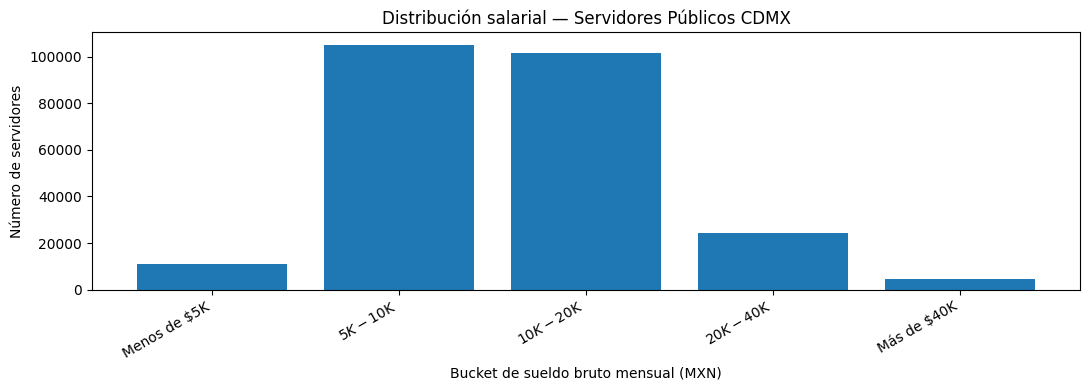

In [3]:
labels = [b.label for b in stats.salary_distribution]
counts = [b.count for b in stats.salary_distribution]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(labels, counts)
ax.set_title("Distribución salarial — Servidores Públicos CDMX")
ax.set_xlabel("Bucket de sueldo bruto mensual (MXN)")
ax.set_ylabel("Número de servidores")
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
fig.tight_layout()
plt.show()

## 3. Distribución por edad

La columna de edad muestra la composición demográfica del padrón.

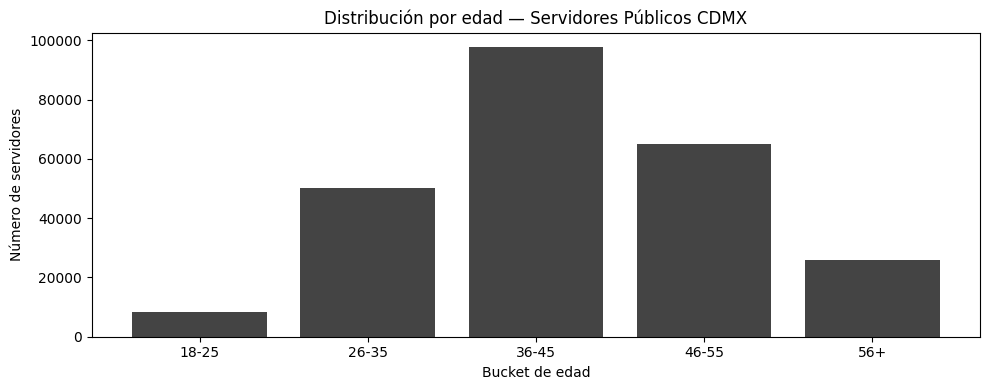

In [4]:
labels = [b.label for b in stats.age_distribution]
counts = [b.count for b in stats.age_distribution]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, counts, color="#444")
ax.set_title("Distribución por edad — Servidores Públicos CDMX")
ax.set_xlabel("Bucket de edad")
ax.set_ylabel("Número de servidores")
fig.tight_layout()
plt.show()

## 4. Top 10 sectores por número de servidores

In [5]:
top15 = pd.DataFrame(
    [
        {
            "sector": s.name,
            "servidores": s.count,
            "sueldo_promedio": round(s.avg_salary, 2),
            "avg_male": round(s.avg_male, 2),
            "avg_female": round(s.avg_female, 2),
        }
        for s in stats.top15_sectors
    ]
)
top15.head(10)

,sector,servidores,sueldo_promedio,avg_male,avg_female
0,SECRETARIA DE SEGURIDAD CIUDADANA DE LA CDMX,49765,16654.41,17125.50,15684.92
1,SECRETARIA DE SALUD DE LA CDMX,23591,17269.21,17268.23,17269.84
2,FISCALIA GENERAL DE JUSTICIA DE LA CIUDAD DE M...,14620,22479.68,23550.25,21152.25
3,SISTEMA DE AGUAS DE LA CIUDAD DE MEXICO,12316,9839.22,9941.81,9492.48
4,ALCALDIA DE IZTAPALAPA,12070,8811.76,8887.52,8714.13
5,ALCALDIA DE GUSTAVO A. MADERO,10661,9384.83,9508.06,9226.13
6,ALCALDIA DE CUAUHTEMOC,9009,9316.04,9376.04,9234.84
7,ALCALDIA DE VENUSTIANO CARRANZA,8349,8874.61,9088.06,8614.86
8,SECRETARIA DE ADMINISTRACION Y FINANZAS DE LA ...,7985,13626.80,14422.75,12919.16
9,ALCALDIA DE COYOACAN,6783,9132.19,9123.96,9143.42


## 5. Brecha de género por bucket de edad

El endpoint `brecha_edad` reporta el sueldo promedio por sexo en cada bucket etario, con `gap_pct` ya calculado.

In [6]:
brecha = client.cdmx.brecha_edad()
df_brecha = pd.DataFrame(
    [
        {
            "bucket": b.bucket_edad,
            "avg_male": round(b.avg_male, 2),
            "avg_female": round(b.avg_female, 2),
            "gap_pct": round(b.gap_pct, 2),
            "count_male": b.count_male,
            "count_female": b.count_female,
        }
        for b in brecha
    ]
)
df_brecha

,bucket,avg_male,avg_female,gap_pct,count_male,count_female
0,18-25,10595.48,10824.54,-2.12,4480,3922
1,26-35,13527.50,13619.71,-0.68,28074,22117
2,36-45,13186.53,12872.04,2.44,57383,40234
3,46-55,14375.36,12973.38,10.81,36175,28665
4,56+,12777.89,12564.33,1.70,14666,11100


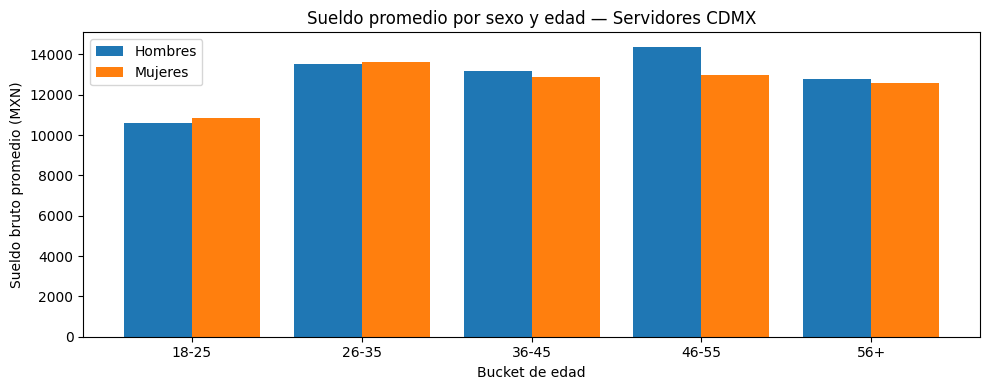

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(df_brecha))
ax.bar([i - 0.2 for i in x], df_brecha["avg_male"], width=0.4, label="Hombres")
ax.bar([i + 0.2 for i in x], df_brecha["avg_female"], width=0.4, label="Mujeres")
ax.set_xticks(list(x))
ax.set_xticklabels(df_brecha["bucket"])
ax.set_xlabel("Bucket de edad")
ax.set_ylabel("Sueldo bruto promedio (MXN)")
ax.set_title("Sueldo promedio por sexo y edad — Servidores CDMX")
ax.legend()
fig.tight_layout()
plt.show()

## Lo que estos datos NO muestran

- **No incluyen el Gobierno Federal**: solo dependencias y entes del Gobierno de la Ciudad de México. Servidores federales con sede en CDMX no aparecen aquí.
- **No incluyen organismos autónomos** (INE, INAI, CDHCM, etc.).
- **Sueldos brutos, no netos**: el bruto es lo que reporta la nómina; el neto es lo que efectivamente recibe el servidor (varía por ISR, ISSSTE, créditos, etc.).
- **Snapshot vigente, no longitudinal**: cada actualización refleja el estado del padrón en ese momento. No es serie temporal.
- **Brecha de género agregada**: el gap por edad NO controla por sector, puesto, antigüedad o nivel salarial. Es descriptivo, no causal.

In [8]:
client.close()